# HNL Analysis v6

In [70]:
%load_ext autoreload
%autoreload 2

import sys
import importlib.util
import pandas as pd
import numpy as np

CAFPYANA_PATH = '/exp/sbnd/data/users/lnguyen/cafpyana_pi0/cafpyana'
ANA_PATH = '/exp/sbnd/data/users/lnguyen/cafpyana_pi0/cafpybara'

sys.path.insert(0, CAFPYANA_PATH)
import makedf.makedf
from makedf.util import InFV

# Load the top-level cafpybara package via spec_from_file_location (bypasses
# sys.path/sys.meta_path resolution -- see the EAF import-shadowing note in
# claude_memory.md). cafpybara.analyses.hnlpi0 is then imported normally
# afterward, resolving against this already-registered, non-shadowed parent.
for _mod in [m for m in sys.modules if m.split('.')[0] == 'cafpybara']:
    del sys.modules[_mod]
spec = importlib.util.spec_from_file_location(
    "cafpybara", ANA_PATH + "/__init__.py",
    submodule_search_locations=[ANA_PATH],
)
_cafpybara = importlib.util.module_from_spec(spec)
sys.modules["cafpybara"] = _cafpybara
spec.loader.exec_module(_cafpybara)

import cafpybara.analyses.hnlpi0 as ana
assert ana.io.__file__ == ANA_PATH + "/analyses/hnlpi0/io.py"

import pickle
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<h1>Selection Mode</h1>

In [71]:
# Choose one:  '1shw', '2shw', 'either_shw', '1shw_angle', '2shw_angle', 'either_angle'
selection_mode = '1shw'

cuts_for_load = ana.PI0_CUT_LISTS[selection_mode]

<h1>Load Files</h1>

In [72]:
FILEPATH = '/exp/sbnd/data/users/lnguyen/cafpyana_pi0/dataframes/July2026/'

DTBNB_FILES = [
    FILEPATH + "dtbnb_fix.df",
    #FILEPATH + "dtbnb_roll.df",  # not yet submitted/concatenated
]
DTOFF_FILE = FILEPATH + "dtoff.df"

MCBNB_FILE = FILEPATH + "mcbnb_cv.df"

# HNL MeVPrtl mass samples (MeV) -> file path. Only m260 has a real concatenated
MCHNL_FILES = {
    140: FILEPATH + "mchnl_nupi0_m140.df",
    165: FILEPATH + "mchnl_nupi0_m165.df",
    190: FILEPATH + "mchnl_nupi0_m190.df",
    215: FILEPATH + "mchnl_nupi0_m215.df",
    240: FILEPATH + "mchnl_nupi0_m240.df",
    260: FILEPATH + "mchnl_nupi0_m260.df",
}
m_list = [260]  # masses to actually load below; only 260 exists for real, see above
#m_list = [140, 165, 190, 215, 240, 260]

rec_tree = "rec"

<h3> Data BNB </h3>

In [73]:
dtbnb_pot = 0
dtbnb_ngates = 0
dtbnb_df = None

for f in DTBNB_FILES:
    thisdf, this_pot, this_ngates = ana.load_data(
        f, onbeam=True, rec_key=rec_tree, cuts=cuts_for_load,
        preprocess_fn=ana.preprocess_databnb,
    )
    dtbnb_pot += this_pot
    dtbnb_ngates += this_ngates

    if dtbnb_df is None:
        dtbnb_df = thisdf
    else:
        dtbnb_df = pd.concat([dtbnb_df, thisdf], ignore_index=True)

print("Data POT: ", dtbnb_pot)


Removing entries with tdcRwm==0: 0
 Remove 0 slices
 Correct 1200 slices
Data POT:  4.62125261085646e+18


<h3>MC BNB</h3>

In [74]:
mcbnb_df, mcbnb_pot, mcbnb_ngen = ana.load_mc(
    MCBNB_FILE,
    rec_key=rec_tree,
    cuts=cuts_for_load,
    preprocess_fn=ana.preprocess_mcbnb,
    define_signal_fn=lambda df: ana.define_signal_pi0(df, prefix=('slc', 'truth')),
    chunk_splits=1,
)

#scale MC neutrino to BNB+Light data using POT
#see SBN-docdb-41013
scale_mcbnb = dtbnb_pot/mcbnb_pot

print("mc pot: ", mcbnb_pot)
print("mc ngen: ", mcbnb_ngen)
print("scale: ", scale_mcbnb)


100%|██████████| 12/12 [00:09<00:00,  1.24it/s]

mc pot:  5.397735827528316e+20
mc ngen:  37434700.0
scale:  0.00856146495219012


<h3>Data Offbeam+Light</h3>

In [75]:
dtoff_df, _, noffbeamgates = ana.load_data(
    DTOFF_FILE, onbeam=False, rec_key=rec_tree, cuts=cuts_for_load,
    preprocess_fn=ana.preprocess_dataoff,
    offbeam_signal_value=ana.signal_dict_hnl['offbeam'],
)

#scale Offbeam+Light
#see SBN-docdb-43255 for fudge factor f
f = 0.0725

ongates_per_pot = dtbnb_ngates / dtbnb_pot
noffbeamscale_mc = ((1- f)*(ongates_per_pot*mcbnb_pot))/noffbeamgates


<h3>MC MeVPrtl HNL</h3>

In [76]:
hnl_dfs_dict = {}
hnl_extra_info_dict = {}

for mass in m_list:
    print(f"Loading HNL mass {mass} MeV...")
    print(MCHNL_FILES[mass])

    mchnl_df, mchnl_pot, mchnl_info = ana.load_mchnl(MCHNL_FILES[mass], rec_key=rec_tree, cuts=cuts_for_load)

    hnl_dfs_dict[mass] = mchnl_df
    hnl_extra_info_dict[mass] = {
        'scale_mchnl': dtbnb_pot / mchnl_pot,
        'simU': mchnl_info['simU'],
        'hnlM': mchnl_info['hnlM'],  # already converted from GeV to MeV by load_mchnl
        # Raw (unscaled) HNL MC POT, needed by ana.get_total_cov's flux/POT weighting.
        'mchnl_pot': mchnl_pot,
    }


Loading HNL mass 260 MeV...
/exp/sbnd/data/users/lnguyen/cafpyana_pi0/dataframes/July2026/mchnl_nupi0_m260.df


<h1> Add weights_mc/systematics/sample columns </h1>

In [77]:
#weights_mc stays raw (mcbnb_pot-equivalent units); POT rescale to dtbnb_pot is applied
#at plot time instead (scale=/scale_nu=/scale_hnl=), matching nueCC's own convention.
mcbnb_df[('weights_mc', '', '', '', '', '')] = 1.0
dtoff_df[('weights_mc', '', '', '', '', '')] = noffbeamscale_mc

#systematics script use this column for POT normalization, so we need to create it here
norm_col = ('flux_pot_norm', '', '', '', '', '')
mcbnb_df[norm_col] = mcbnb_df[('weights_mc', '', '', '', '', '')] / (ana.integrated_flux * (mcbnb_pot / 1e6))
dtoff_df[norm_col] = dtoff_df[('weights_mc', '', '', '', '', '')] / (ana.integrated_flux * (mcbnb_pot / 1e6))

for mass in m_list:
    hnl_dfs_dict[mass][norm_col] = hnl_dfs_dict[mass][('weights_mc', '', '', '', '', '')] / (ana.integrated_flux * (hnl_extra_info_dict[mass]['mchnl_pot'] / 1e6))


<h1>Merge Data Offbeam+Light and MC BNB, Add MC Stats</h1>

In [78]:
mcstat_cols = ['__ntuple', 'entry', 'rec.slc..index', 'run', 'subrun', 'evt', 'sample', 'file_idx']

mcbnb_df = pd.concat([
    ana.mcstat(mcbnb_df.assign(sample=0).set_index("sample", append=True).reset_index(), cols=mcstat_cols),
    dtoff_df.assign(sample=1).set_index("sample", append=True).reset_index(),
])

for mass in m_list:
    hnl_dfs_dict[mass] = ana.mcstat(
        hnl_dfs_dict[mass].assign(sample=0).set_index("sample", append=True).reset_index(),
        cols=mcstat_cols,
    )


MCstat universes: 100%|██████████| 8743/8743 [00:00<00:00, 56148.57it/s]


<h1> Systematics </h1>

In [79]:
var = ('slc', 'barycenterFM', 'flashTime_calib_mod')
bins = np.linspace(0, 19, 20)

In [80]:
hnl_detvar_dict = ana.load_detvar_dict(ana.config.HNL_DETVAR_DIR + "/detvars.h5")

Loaded 9 detvar group(s) from /exp/sbnd/data/users/lnguyen/cafpyana_pi0/dataframes/July2026/detvar/detvars.h5  [preprocess: none]
  Keys: ['0p94xly_0', '1p19xly_0', 'calo_Ccal', 'calo_alpha', 'calo_beta90', 'calo_R', 'calo_phi', 'calo_yz', 'calo_Ecorr']
  Column check: OK (all DV/CV column sets match)


In [81]:
def hnl_systs_input(pot, include_detv=True):
    uncertainty_keys = {'rate', 'norm'}
    if include_detv:
        uncertainty_keys.add('detv')
    return ana.SystematicsInput(
        mcbnb_pot=pot,
        uncertainty_keys=uncertainty_keys,
        event_type='all',
        select_region='all',  # HNL has no fixed cut sequence -- see detvars.h5 build note
        detvar_dict=hnl_detvar_dict,
        # Without this, get_total_cov's own cuts=None default means _needs_select is
        # False inside get_detvar_systs, so the detvar CV/DV comparison runs on the
        # full preselection-only population instead of this analysis's actual
        # selection -- inflates DetVar's uncertainty (numerator on ~131876 unselected
        # events, denominator on the ~23835-event selected rate_hist_cv). Passing
        # cuts_for_load here keeps both sides population-matched; it's a no-op for
        # HNL's own call since include_detv=False there skips get_detvar_systs entirely.
        cuts=cuts_for_load,
    )

mc_syst_output = ana.get_total_cov(
    mcbnb_df,
    reco_var=var,
    bins=bins,
    **hnl_systs_input(mcbnb_pot).to_kwargs(),
)

Running through multisims: 100%|██████████| 4/4 [00:00<00:00, 73.25it/s]


Applying selection to detector variation samples...


9it [00:04,  1.99it/s]


In [82]:
signal_output_dict = {}

for mass in m_list:
    hnl_syst_output = ana.get_total_cov(
        hnl_dfs_dict[mass],
        reco_var=var,
        bins=bins,
        **hnl_systs_input(hnl_extra_info_dict[mass]['mchnl_pot'], include_detv=False).to_kwargs(),
    )
    signal_output_dict[mass] = hnl_syst_output

Running through multisims: 100%|██████████| 8/8 [00:00<00:00, 97.74it/s]


<h1>Plot MC BNB + DATA BNB</h1>

(0.0, 30.0)

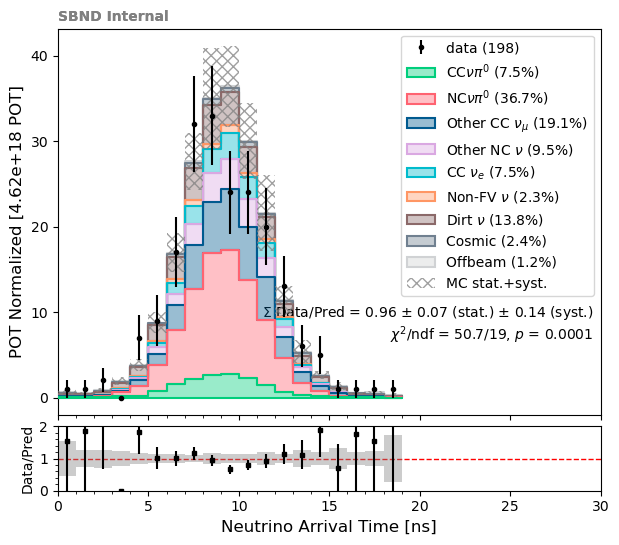

In [83]:
_,ax_main, ax_sub, mcbnb_dict = ana.plot_mc_data(
                          mc_df  = mcbnb_df,
                          data_df = dtbnb_df,
                          var=var,
                          bins=bins,
                          # signal column uses the HNL scheme (define_signal_pi0/hnl),
                          # so categories must be background_categories_hnl, not
                          # master's nueCC signal_categories default.
                          categories=ana.background_categories_hnl,
                          ylabel=f"POT Normalized [{dtbnb_pot:.2e} POT]",
                          xlabel='Neutrino Arrival Time [ns]',
                          percents=True,
                          systs = mc_syst_output,
                          scale = scale_mcbnb,
                          bin_labels = None,
                          legend_kwargs={'loc': 'upper right', 'ncol': 1},
                          cut_val = [],
                          title = None,
                          )
ax_main.set_xlim(0,30)
ax_sub.set_xlim(0,30)

<h1>Plot MC BNB + DATA BNB + MC HNL</h1>

1 6496414004469.09 6496414004469.09


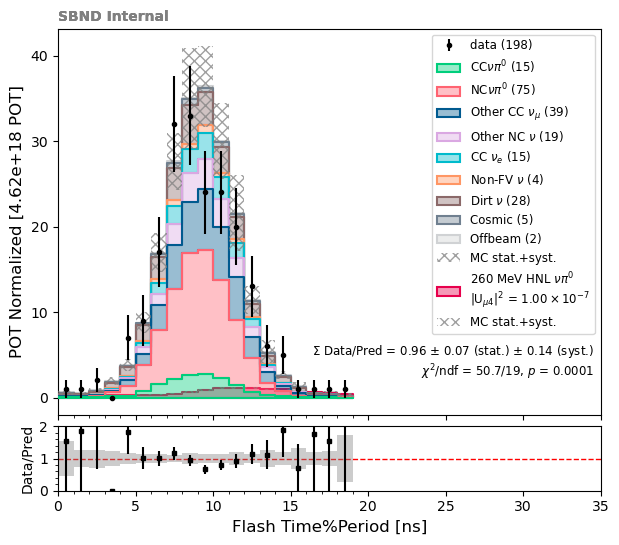

In [84]:
result_bnb_dict = {}
result_hnl_dict = {}

signal_plots_cfg = ana.PlottingConfig(
    ylabel=f"POT Normalized [{dtbnb_pot:.2e} POT]",
    xlabel="Flash Time%Period [ns]",
    categories=ana.background_categories_hnl,
    systs=mc_syst_output,
    counts=True,
    legend_kwargs={'loc': 'upper right', 'ncol': 1, 'fontsize': 8.5},
)

for mass in m_list:

    # scale_hnl_display is purely a display-visibility boost (HNL_DISPLAY_SCALE[mass]) --
    # it also feeds plotU = simU*sqrt(scale) for the legend's |U|^2 label, so it must be
    # kept separate from the mchnl POT rescale (scale_mchnl) below, or the label would be
    # wrong. scale_hnl_plot composes both for the actual histogram-height multiplier.
    scale_hnl_display, saveU, hnl_categories = ana.hnl_categories_for_mass(mass, hnl_extra_info_dict[mass]['simU'])
    scale_hnl_plot = hnl_extra_info_dict[mass]['scale_mchnl'] * scale_hnl_display
    print(scale_hnl_display, scale_hnl_plot, hnl_extra_info_dict[260]['scale_mchnl'])

    fig, ax_main, ax_sub, mc_dict, hnl_dict, dt_dict = ana.plot_mc_hnl_data(
        mc_df=mcbnb_df,
        hnl_df=hnl_dfs_dict[mass],
        data_df=dtbnb_df,
        var=var,
        bins=bins,
        scale_nu=scale_mcbnb,
        scale_hnl=scale_hnl_plot,
        hnl_categories=hnl_categories,
        hnl_systs=signal_output_dict[mass],
        config=signal_plots_cfg,
        cut_val=[],
        title=None,
        )
    ax_main.set_xlim(0, 35)
    ax_sub.set_xlim(0, 35)

    result_bnb_dict = mc_dict
    result_hnl_dict[mass] = {}
    result_hnl_dict[mass]['saveU'] = saveU
    result_hnl_dict[mass]['result'] = hnl_dict

<h1>Systematics Breakdown</h1>

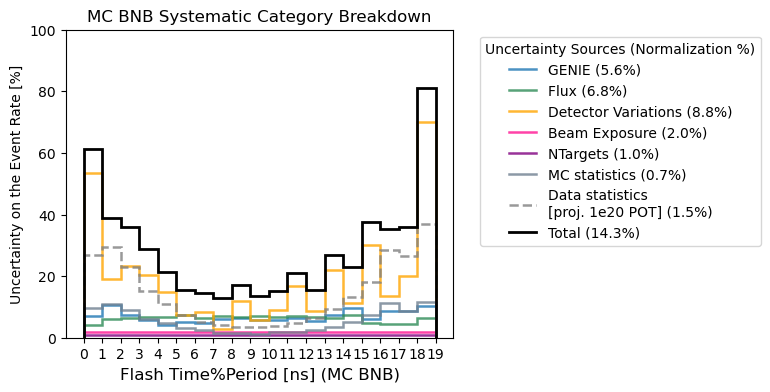

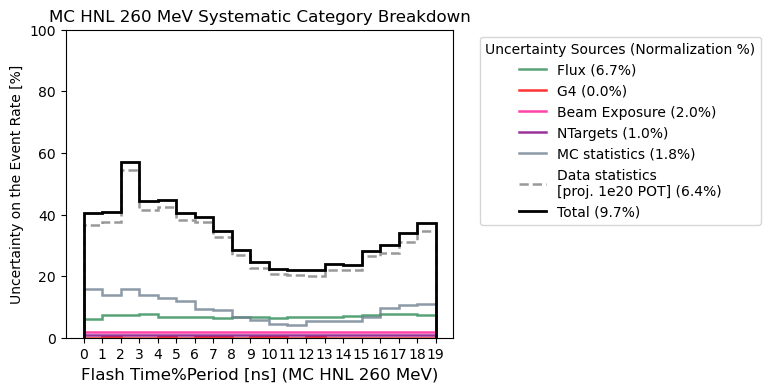

In [85]:
# CHANGED: one plot_syst_category_breakdown call per sample instead of one call with
# both samples as subplot columns. MC BNB and HNL have non-overlapping systematic
# category coverage (HNL carries no GENIE knobs at all), so keeping them as separate
# figures/legends is clearer than a shared side-by-side layout.

fig_mc, axes_mc, cats_mc, cat_sums_mc = ana.plot_syst_category_breakdown(
    syst_vars=[(mc_syst_output, bins, "Flash Time%Period [ns] (MC BNB)")],
    category_dict=ana.category_dict_signal,
    region_label=""
)
plt.ylim(0,100)
plt.title("MC BNB Systematic Category Breakdown")
plt.show()

for mass in m_list:
    fig_hnl, axes_hnl, cats_hnl, cat_sums_hnl = ana.plot_syst_category_breakdown(
        syst_vars=[(signal_output_dict[mass], bins, f"Flash Time%Period [ns] (MC HNL {mass} MeV)")],
        category_dict=ana.category_dict_signal,
        region_label="",
    )
    plt.title(f"MC HNL {mass} MeV Systematic Category Breakdown")
    plt.ylim(0,100)
    plt.show()


<h3>Per-source drill-down (bonus)</h3>

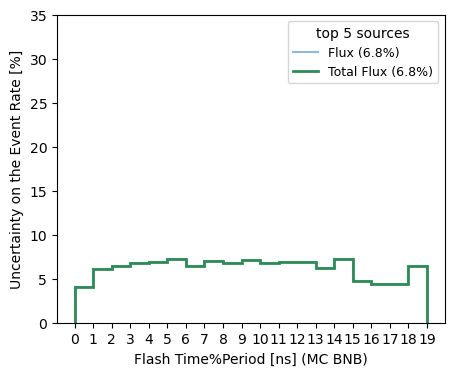

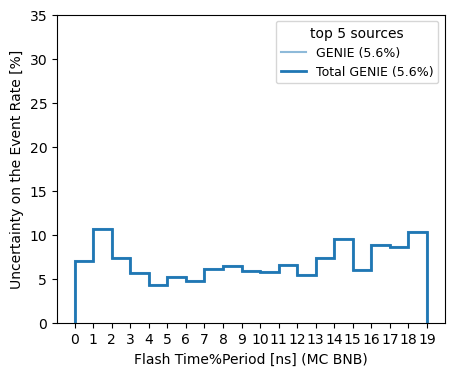

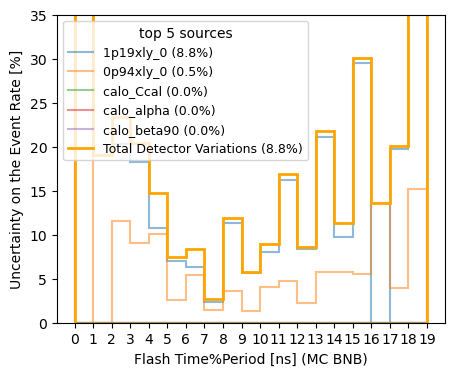

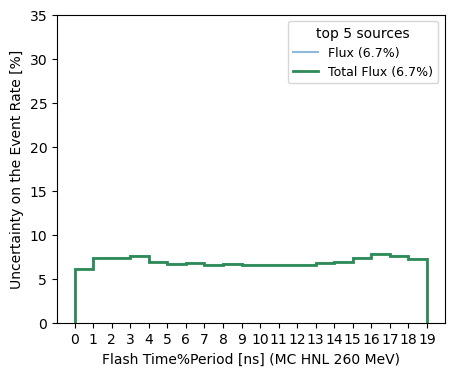

In [91]:
cat_list = ['Flux', 'GENIE', 'DetVar']
for c in cat_list:
    if c == 'DetVar':
        fig_mc_detv, axes_mc_detv = ana.plot_syst_breakdown(
            syst_vars=[(mc_syst_output, bins, "Flash Time%Period [ns] (MC BNB)")],
            category=c,
            category_dict=ana.category_dict_signal,
        )
        plt.show()
    else:
        fig_mc, axes_mc = ana.plot_syst_breakdown(
            syst_vars=[(mc_syst_output, bins, "Flash Time%Period [ns] (MC BNB)")],
            category=c,
        category_dict=ana.category_dict_signal,
        )
        plt.show()

for mass in m_list:
    fig_hnl, axes_hnl = ana.plot_syst_breakdown(
        syst_vars=[(signal_output_dict[mass], bins, f"Flash Time%Period [ns] (MC HNL {mass} MeV)")],
        category='Flux',
        category_dict=ana.category_dict_signal,
    )
    plt.show()


<h1>Save Dictionary For PYHF</h1>

In [87]:
print('dtbnb_pot: ', dtbnb_pot)


dtbnb_pot:  4.62125261085646e+18


In [88]:
# CHANGED: v4 referenced ifSave/ifIncludeData without defining them anywhere in the
# notebook -- they had to already be set interactively, otherwise every guarded cell
# below just raises SystemExit. Defaulting both to explicit, visible values here.
ifSave = False
ifIncludeData = True

if not ifSave:
    print("ifSave is set to False. Set it to True above to save pyhf input dictionaries.")
    sys.exit()


ifSave is set to False. Set it to True above to save pyhf input dictionaries.


SystemExit: 

/home/lnguyen/.conda/envs/venv_eaf/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3675: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
#Configure output paths and filenames for pyhf inputs
save_path = '/exp/sbnd/data/users/lnguyen/cafpyana_pi0/pyhf_inputs/'
print("Saving pyhf inputs to: ", save_path)

suffix = 'tradcut'
#suffix = 'bdt'

if ifIncludeData:
    suffix += '_data'
    dtbnb_filename = 'dtbnb_dict_{}.pkl'.format(suffix)
    print("Data BNB filename: ", dtbnb_filename)

mcbnb_filename = 'mcbnb_dict_{}.pkl'.format(suffix)
print("MC BNB filename: ", mcbnb_filename)

for mass in m_list:
    mchnl_filename = 'mchnl_dict_{}_{}.pkl'.format(int(mass), suffix)
    print("MC HNL filename: ", mchnl_filename)


In [ ]:
#systematic list
syst_list = ['Flux', 'GENIE', 'reinteractions_piminus_Geant4', 'reinteractions_piplus_Geant4', 'reinteractions_proton_Geant4']


<h3> MC BNB + Data Offbeam </h3>

In [ ]:
if not ifSave:
    print("ifSave is set to False. Skipping saving pyhf input dictionaries.")
    sys.exit()

mcbnb_stat_cov = np.diag(result_bnb_dict['counts'])
mcbnb_stat_err = np.sqrt(np.diag(mcbnb_stat_cov))

mcbnb_tosave_dict = {
    'bins': result_bnb_dict['bins'],
    'counts': result_bnb_dict['counts'],
    'POT': dtbnb_pot,
    'total_err': result_bnb_dict['total_err'],
    'stat_err': mcbnb_stat_err,
}

# CHANGED (fix): v4 iterated the stale `mc_dict` loop leftover here instead of
# `result_bnb_dict`; they only happened to match by accident (last-mass assignment order).
for k,v in result_bnb_dict.items():
    if k in syst_list:
        error_name = k+'_err'
        mcbnb_tosave_dict[error_name] = np.sqrt(np.diag(v['cov']))


for k,v in mcbnb_tosave_dict.items():
    print(f"{k}: {v}")

print("Saving MC BNB dictionary for pyhf input...")
with open(save_path + mcbnb_filename, 'wb') as f:
    pickle.dump(mcbnb_tosave_dict, f)


<h3>MC HNL</h3>

In [ ]:
if not ifSave:
    print("ifSave is set to False. Skipping saving pyhf input dictionaries.")
    sys.exit()

for mass in m_list:
    hnl_dict = result_hnl_dict[mass]['result']
    saveU = result_hnl_dict[mass]['saveU']

    mchnl_stat_cov = np.diag(hnl_dict['counts'])
    mchnl_stat_err = np.sqrt(np.diag(mchnl_stat_cov))

    mchnl_tosave_dict = {
        'bins': hnl_dict['bins'],
        'counts': hnl_dict['counts'],
        # CHANGED (fix): use this mass's own hnlM (saved per-mass at load time)
        # instead of v4's leftover last-iteration global `hnlM`.
        'm': hnl_extra_info_dict[mass]['hnlM'],
        'U': saveU,
        'POT': dtbnb_pot,
        'total_err': hnl_dict['total_err'],
        'stat_err': mchnl_stat_err,
    }

    for k,v in hnl_dict.items():
        if k in syst_list:
            error_name = k+'_err'
            mchnl_tosave_dict[error_name] = np.sqrt(np.diag(v['cov']))

    mchnl_filename = 'mchnl_dict_{}_{}.pkl'.format(int(mass), suffix)
    print(f"Saving MC HNL filename: {mchnl_filename} dictionary for pyhf input...")
    with open(save_path+mchnl_filename, 'wb') as f:
        pickle.dump(mchnl_tosave_dict, f)


<h3>Data BNB</h3>

In [ ]:
if not ifSave:
    print("ifSave is set to False. Skipping saving pyhf input dictionaries.")
    sys.exit()

if ifIncludeData:
    dtbnb_stat_cov = np.diag(dt_dict['counts'])
    dtbnb_stat_err = np.sqrt(np.diag(dtbnb_stat_cov))

    dt_tosave_dict = {
        'bins': dt_dict['bins'],
        'counts': dt_dict['counts'],
        'POT': dtbnb_pot,
        'total_err': dt_dict['total_err'],
        'stat_err': dtbnb_stat_err,
    }

    print(f"Saving data bnb dictionary for pyhf input...")
    with open(save_path + dtbnb_filename, 'wb') as f:
        pickle.dump(dt_tosave_dict, f)
